In [39]:
!pip install scikeras

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from scikeras.wrappers import KerasClassifier

from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, log_loss
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import MinMaxScaler

In [41]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [42]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

X_train = X_train / 255.0
X_test = X_test / 255.0

#feature scaling
minimax_scaler = MinMaxScaler()

X_train = minimax_scaler.fit_transform(X_train)
X_test = minimax_scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

print('Number of classes: ', len(np.unique(y_train)))
print('Number of samples in training set: ', len(X_train))

print('Classes: ', np.unique(y_train))

(60000, 784)
(10000, 784)
Number of classes:  10
Number of samples in training set:  60000
Classes:  [0 1 2 3 4 5 6 7 8 9]


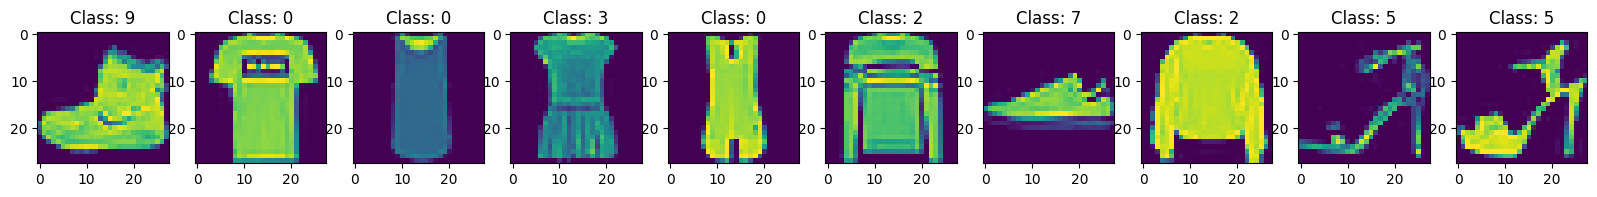

In [43]:
fig, axes = plt.subplots(1, 10, figsize=(20, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].set_title(f'Class: {y_train[i]}')

plt.subplots_adjust(hspace=0.5)
plt.show()

In [44]:
#initializing the model
fashion_model = Sequential()

#add first hidden layer with 256 neurons and relu activation function
fashion_model.add(Dense(input_dim = X_train.shape[1], units = 256, kernel_initializer='he_normal', activation = 'relu'))

#add output layer
fashion_model.add(Dense(units = 10, kernel_initializer='he_normal', activation = 'softmax'))

#compile the model
fashion_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

#model summary
fashion_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model_fit = fashion_model.fit(X_train, y_train, validation_split = 0.1, epochs = 20, verbose = 1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8270 - loss: 0.4881 - val_accuracy: 0.8643 - val_loss: 0.3774
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8676 - loss: 0.3644 - val_accuracy: 0.8752 - val_loss: 0.3470
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8796 - loss: 0.3293 - val_accuracy: 0.8647 - val_loss: 0.3536
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8891 - loss: 0.3025 - val_accuracy: 0.8717 - val_loss: 0.3437
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8940 - loss: 0.2836 - val_accuracy: 0.8838 - val_loss: 0.3384
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8993 - loss: 0.2690 - val_accuracy: 0.8882 - val_loss: 0.3175
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9040 - loss: 0.2574 - val_accuracy: 0.8712 - val_loss: 0.3628
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9095 - loss: 0.2445 -

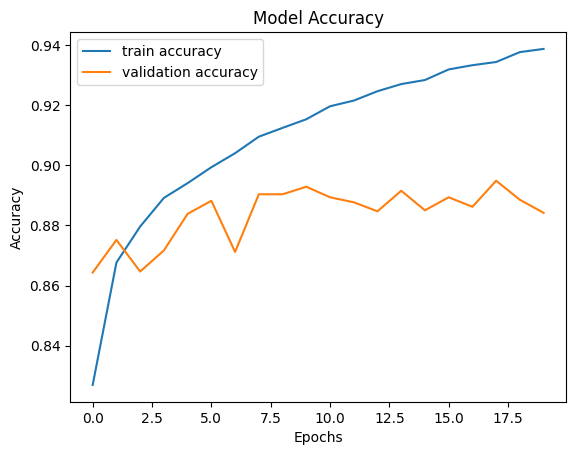

In [46]:
plt.plot(model_fit.history['accuracy'], label = 'train accuracy')
plt.plot(model_fit.history['val_accuracy'], label = 'validation accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

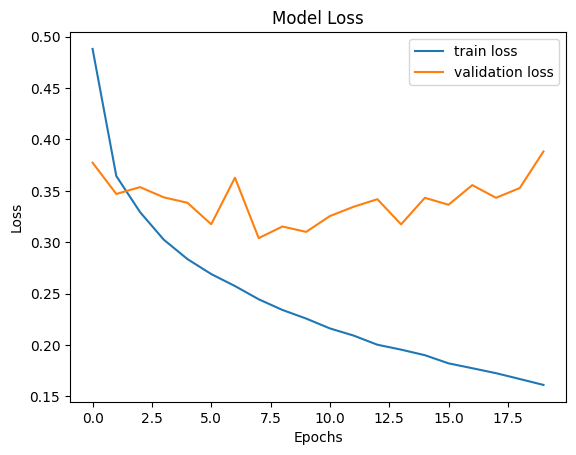

In [47]:
plt.plot(model_fit.history['loss'], label = 'train loss')
plt.plot(model_fit.history['val_loss'], label = 'validation loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [48]:
print(np.argmax(fashion_model.predict(X_test)[0]), y_test[0])
print(np.argmax(fashion_model.predict(X_test)[10]), y_test[10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
9 9
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
4 4


In [49]:
mnist_train_path = "/content/sample_data/mnist_train_small.csv"
mnist_test_path = "/content/sample_data/mnist_test.csv"

mnist_train = pd.read_csv(mnist_train_path)
mnist_test = pd.read_csv(mnist_test_path)

print(mnist_train.shape)
print(mnist_test.shape)

(19999, 785)
(9999, 785)


In [50]:
X_train = mnist_train.iloc[:, 1:]
X_test = mnist_test.iloc[:,1:]
print(X_train.shape)

y_train = mnist_train.iloc[:,0]
y_test = mnist_test.iloc[:,0]

print('Number of classes: ', len(np.unique(y_train)))
print('Classes: ', np.unique(y_train))

(19999, 784)
Number of classes:  10
Classes:  [0 1 2 3 4 5 6 7 8 9]


In [51]:
from keras import Optimizer
model = Sequential()
model.add(Dense(input_dim=X_train.shape[1],units=256,kernel_initializer='he_normal',activation='relu'))
model.add(Dense(units=10, kernel_initializer='he_normal',activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model_fit = model.fit(X_train, y_train, epochs=30,verbose=1)

print(np.argmax(model.predict(X_test)[0]), y_test[0])
print(np.argmax(model.predict(X_test)[10]), y_test[10])

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8655 - loss: 7.1849 
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9292 - loss: 1.1800
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9454 - loss: 0.6275
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9553 - loss: 0.4683
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9595 - loss: 0.3866
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9587 - loss: 0.3868
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9614 - loss: 0.3132
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9650 - loss: 0.2947
Epoch 9/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9648 - loss: 0.2803
Epoch 10/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9644 - loss: 0.2817
Epoch 11/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9682 - loss: 0.2411
Epoch 12/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/ste

In [60]:
img_size = (28, 28)

img = tf.keras.preprocessing.image.load_img(
    '/content/sneaker.jpg', color_mode='grayscale', target_size=img_size)

img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.squeeze(img_array)
img = np.reshape(img_array, (784,))
img_array = tf.expand_dims(img, 0)
img_array = tf.convert_to_tensor(img_array)
print(img_array.shape)
#print(img_array.reshape(None, 784))

img_predict = model.predict(img_array)
print(img_predict)
score = np.argmax(img_predict)
print(score)

(1, 784)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
2
